In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

In [ ]:
# ==========================================================
# PART A — DATASET
# ==========================================================

def generate_dataset(n=100, seed=42):
    # Generate a 2D linearly separable dataset.
    # Requirements:
    # - Use fixed random seed
    # - Labels must be {-1, +1}
    # - Return X (n,2), y (n,)
    
    np.random.seed(seed)

    n1 = n // 2 # // is the floor division operator, which divides and returns the largest integer less than or equal to the result
    n2 = n - n1 # ensures that if n is odd, the total number of samples is still n
    # Generate two clusters of points that are linearly separable
    X_pos = np.random.randn(n1, 2) * 0.6 + np.array([3, 1])
    X_neg = np.random.randn(n2, 2) * 0.6 + np.array([-3, -1])
    # Stack the positive and negative samples together
    X = np.vstack((X_pos, X_neg))
    y = np.hstack((np.ones(n1), -np.ones(n2)))
    
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title("Generated Linearly Separable Dataset")
    plt.show()

    return X, y # X is the feature matrix and y is the label vector

In [ ]:
# ==========================================================
# PART B — TRAIN LINEAR SVM
# ==========================================================

def train_linear_svm(X, y):
    # Train a linear SVM using sklearn.
    # Instructions:
    # - Use kernel='linear'
    # - Fit the model
    # - Return trained model
    # DO NOT modify dataset.
    model = SVC(kernel="linear", C=1e6)# C is the regularization parameter, which controls the trade-off between achieving a low error on the training data and minimizing the model complexity for better generalization to unseen data. A large value of C (like 1e6) means that the model will try to fit the training data as well as possible, even if it means having a more complex decision boundary.
    model.fit(X, y)
    return model

In [15]:
# ==========================================================
# PART C — EXTRACT PARAMETERS
# ==========================================================

def extract_parameters(model):
    # Extract:
    #     w (weight vector)
    #     b (bias term)

    # Hint:
    #     model.coef_
    #     model.intercept_

    # Return:
    #     w, b
    
    w = model.coef_[0]
    b = model.intercept_[0]

    print("Weight vector w:", w)
    print("Bias b:", b)
    print("||w||:", np.linalg.norm(w))

    return w, b


In [16]:
# ==========================================================
# PART D — CONSTRAINT VERIFICATION
# ==========================================================

def compute_margins(X, y, w, b):
    # Compute:
    #     y_i (w^T x_i + b)
    # Return:
    #     array of margins
    return y * (X @ w + b)


def verify_constraints(margins):
    # Print:
    #     - Minimum margin value
    #     - Whether all margins >= 1
    # DO NOT modify margins.
    print("Minimum margin value:", np.min(margins))
    print("All margins >= 1:", np.all(margins >= 1))

In [17]:
# ==========================================================
# PART E — GEOMETRIC MARGIN
# ==========================================================

def compute_margin_width(w):
    # Compute geometric margin width:
    #     2 / ||w||
    # Return scalar.
    return 2 / np.linalg.norm(w) # .norm(w) computes the Euclidean norm (L2 norm) of the weight vector w.

In [18]:
# ==========================================================
# PART F — SUPPORT VECTORS
# ==========================================================

def analyze_support_vectors(model, X, y, w, b):
    # Tasks:
    # 1. Print indices of support vectors.
    # 2. Print number of support vectors.
    # 3. Verify numerically that support vectors
    #    approximately satisfy:
    #         y_i (w^T x_i + b) ≈ 1
    print("Support vector indices:", model.support_)
    print("Number of support vectors:", len(model.support_))

    margins = y * (X @ w + b)
    print("Margins of support vectors (≈ 1):")
    print(margins[model.support_])


In [ ]:
# ==========================================================
# PART G — REMOVE ONE SUPPORT VECTOR
# ==========================================================

def remove_one_support_vector(model, X, y):
    # Remove the first support vector from dataset.
    # Steps:
    # 1. Identify index using model.support_
    # 2. Remove from X and y
    # 3. Return new X, y
    # DO NOT retrain inside this function.
    
    idx = model.support_[0]
    X_new = np.delete(X, idx, axis=0)
    y_new = np.delete(y, idx, axis=0)
    print("Removed support vector index:", idx)
    return X_new, y_new


In [20]:
# ==========================================================
# PART H — SCALING EXPERIMENT
# ==========================================================

def scale_dataset(X, factor):
    # Multiply features by scaling factor.
    # Return scaled X.
    return X * factor

In [21]:
# ==========================================================
# PROVIDED PLOTTING FUNCTION
# ==========================================================

def plot_model(X, y, model, title="Model"):
    # Provided plotting function.
    # Students should call this,
    # not modify it.
    
    
    plt.figure()

    plt.scatter(X[:, 0], X[:, 1], c=y)

    w = model.coef_[0]
    b = model.intercept_[0]

    x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    y_vals = -(w[0] * x_vals + b) / w[1]

    plt.plot(x_vals, y_vals)

    y_margin1 = -(w[0]*x_vals + b - 1) / w[1]
    y_margin2 = -(w[0]*x_vals + b + 1) / w[1]

    plt.plot(x_vals, y_margin1, '--')
    plt.plot(x_vals, y_margin2, '--')

    plt.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=150, facecolors='none', edgecolors='black')

    plt.title(title)
    plt.show()

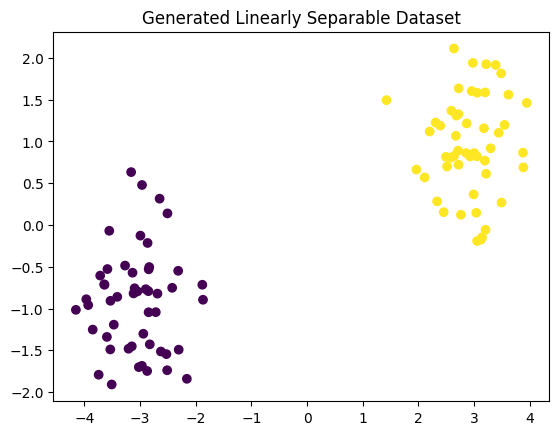

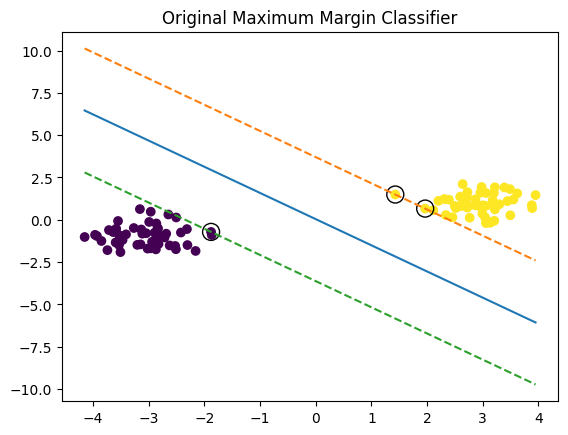

Weight vector w: [0.42214992 0.27290415]
Bias b: -0.010524330571816875
||w||: 0.5026800470280305
Minimum margin value: 0.9997097189632844
All margins >= 1: False
Geometric margin width: 3.9786739334980523
Support vector indices: [78  7 37]
Number of support vectors: 3
Margins of support vectors (≈ 1):
[0.99970972 0.99985486 0.99985483]
Removed support vector index: 78


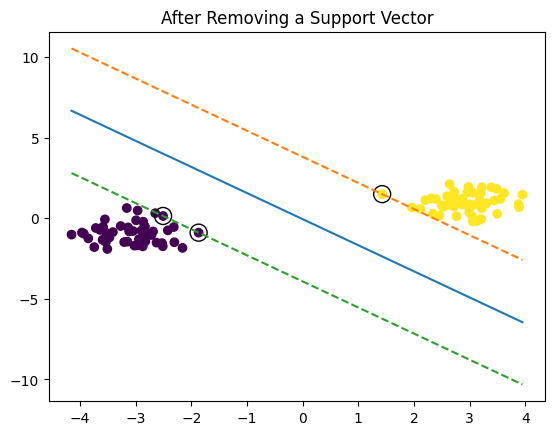

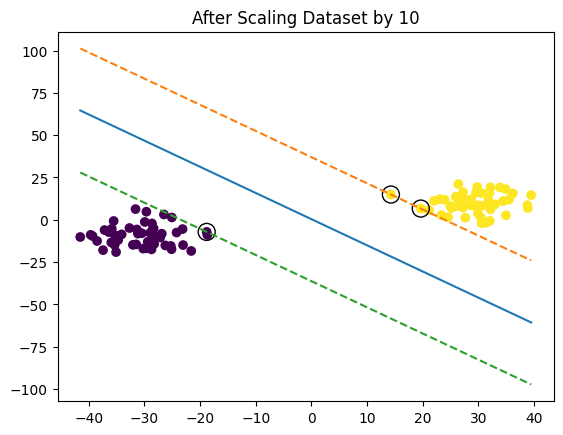

In [ ]:
# ==========================================================
# MAIN EXECUTION (RUN STEP BY STEP)
# ==========================================================

if __name__ == "__main__":

    # Step 1
    X, y = generate_dataset()

    # Step 2
    model = train_linear_svm(X, y)
    plot_model(X, y, model, "Original Maximum Margin Classifier")

    # Step 3
    w, b = extract_parameters(model)

    # Step 4
    margins = compute_margins(X, y, w, b)
    verify_constraints(margins)

    # Step 5
    margin_width = compute_margin_width(w)
    print("Geometric margin width:", margin_width)

    # Step 6
    analyze_support_vectors(model, X, y, w, b)

    # Step 7
    X_new, y_new = remove_one_support_vector(model, X, y)
    model_new = train_linear_svm(X_new, y_new)
    plot_model(X_new, y_new, model_new, "After Removing a Support Vector")

    # Step 8
    X_scaled = scale_dataset(X, factor=10)
    model_scaled = train_linear_svm(X_scaled, y)
    plot_model(X_scaled, y, model_scaled, "After Scaling Dataset by 10")